# Practice Lab - ReLU Activation
### Understanding why non-linear activations (ReLU) matter — Shipping Cost Example

This notebook covers the same concept as the course's ReLU lab, but rebuilt from scratch with a
different, self-contained example: **modeling a tiered shipping-cost function** with a small
neural network that uses ReLU activations.

No external course helper files are needed — everything here runs with just `numpy`,
`matplotlib`, `ipywidgets`, and `tensorflow`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from ipywidgets import interact, FloatSlider
import warnings
warnings.simplefilter(action='ignore', category=UserWarning)

plt.rcParams['figure.figsize'] = (7, 4)
np.random.seed(1)


I0000 00:00:1787243123.905039     517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787243123.948247     517 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787243125.522351     517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1 - The ReLU Activation

The Rectified Linear Unit (ReLU) is defined as:

$$ a = \max(0, z) $$

Unlike the sigmoid, which squashes every input into the range (0, 1), the ReLU passes positive
values through unchanged and simply "turns off" (outputs 0) for negative values. This on/off
behavior is what allows a network to build up complex, piecewise shapes.

Let's compare **Linear**, **Sigmoid**, and **ReLU** side by side.


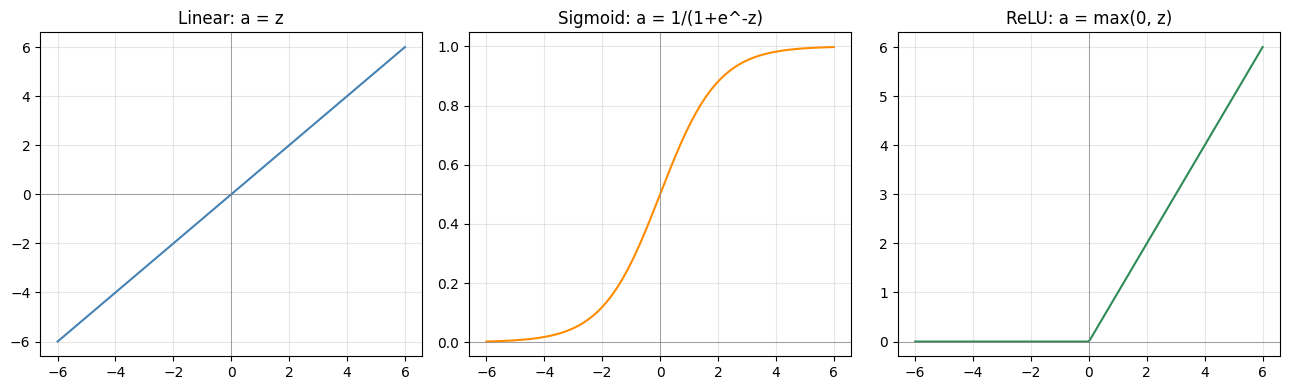

In [2]:
z = np.linspace(-6, 6, 200)

linear_out = z
sigmoid_out = 1 / (1 + np.exp(-z))
relu_out = np.maximum(0, z)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(z, linear_out, color='steelblue')
axes[0].set_title('Linear: a = z')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].grid(alpha=0.3)

axes[1].plot(z, sigmoid_out, color='darkorange')
axes[1].set_title('Sigmoid: a = 1/(1+e^-z)')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].grid(alpha=0.3)

axes[2].plot(z, relu_out, color='seagreen')
axes[2].set_title('ReLU: a = max(0, z)')
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].axvline(0, color='gray', linewidth=0.5)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 2 - Why Do We Need Non-Linear Activations?

Suppose a courier company charges for a package based on its weight, but the price **per kg
changes at certain weight thresholds** (this is extremely common — utility bills, tax brackets,
and shipping rates all work this way):

| Weight range (kg) | Rule |
|---|---|
| 0 – 2 kg   | 5 + 2·w |
| 2 – 5 kg   | 9 + 1·(w − 2) |
| 5 kg +     | 12 + 3·(w − 5) |

This is a **piecewise linear function** — the slope (price per kg) changes at `w = 2` and `w = 5`.
A single linear model `cost = a + b·w` can only ever draw ONE straight line — it can never bend
to match this. We need something that can "turn on" extra slope only past a certain point.
That's exactly what a ReLU unit does.

Let's plot the true target function first.


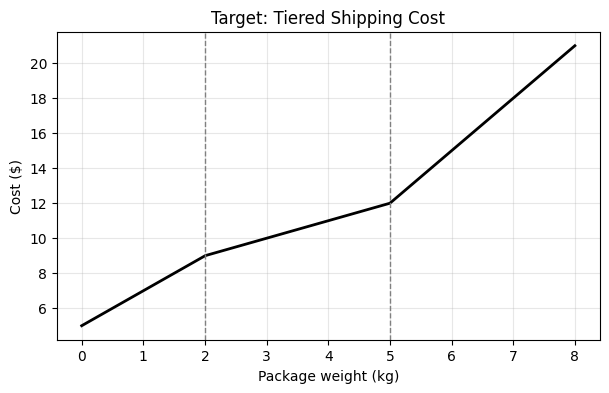

In [3]:
def shipping_cost(w):
    w = np.asarray(w, dtype=float)
    cost = np.where(
        w <= 2,
        5 + 2 * w,
        np.where(
            w <= 5,
            9 + 1 * (w - 2),
            12 + 3 * (w - 5)
        )
    )
    return cost

weights = np.linspace(0, 8, 400)
target = shipping_cost(weights)

plt.plot(weights, target, color='black', linewidth=2)
plt.axvline(2, color='gray', linestyle='--', linewidth=1)
plt.axvline(5, color='gray', linestyle='--', linewidth=1)
plt.title('Target: Tiered Shipping Cost')
plt.xlabel('Package weight (kg)')
plt.ylabel('Cost ($)')
plt.grid(alpha=0.3)
plt.show()


## 3 - Building the Target Out of ReLU Units

A neat trick: **any piecewise linear function can be written as a base line plus a sum of
shifted ReLUs**:

$$ f(w) = a_0 + b_0 \cdot w \;+\; c_1 \cdot \text{ReLU}(w - t_1) \;+\; c_2 \cdot \text{ReLU}(w - t_2) $$

- `a0, b0` set the starting slope/intercept (segment 1)
- Each `ReLU(w - t_i)` is exactly 0 before the breakpoint `t_i`, and grows linearly after it
- `c_i` is the **change in slope** introduced at that breakpoint (it can be negative!)

For our shipping example, matching the table above gives:

- `a0 = 5`, `b0 = 2` &nbsp;→ segment 1 slope = 2
- `t1 = 2`, `c1 = -1` &nbsp;→ segment 2 slope = 2 + (-1) = 1
- `t2 = 5`, `c2 = +2` &nbsp;→ segment 3 slope = 1 + 2 = 3

This is precisely what a tiny neural network with **one hidden layer of ReLU units** computes:
each hidden unit learns a breakpoint `t_i`, and the output layer learns the slope-change `c_i`.


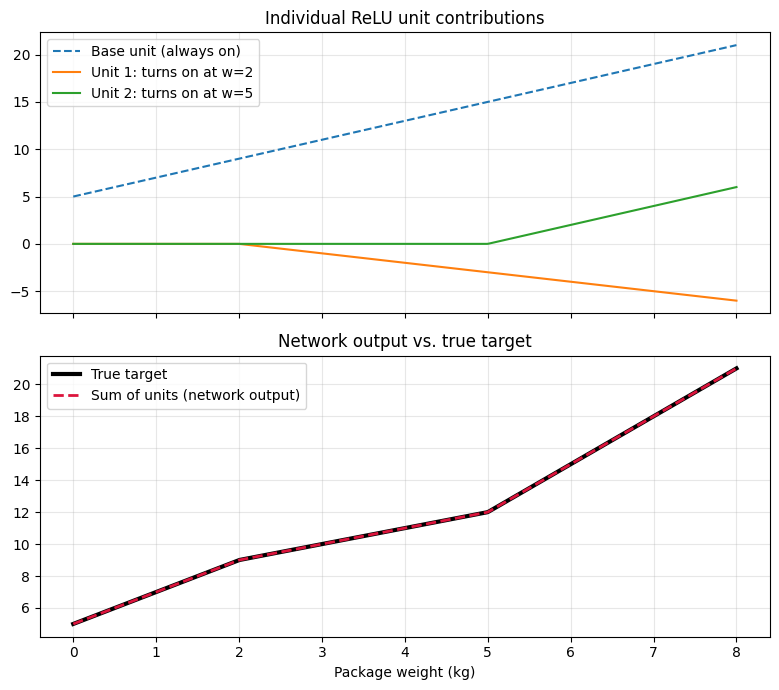

Max error between hand-built network and target: 0.000000


In [4]:
def relu(z):
    return np.maximum(0, z)

def small_relu_network(w, a0=5, b0=2, t1=2, c1=-1, t2=5, c2=2):
    """A 1-hidden-layer network with 2 ReLU units, matching the shipping cost function."""
    base = a0 + b0 * w                 # always-on linear unit (no ReLU needed, w >= 0)
    unit1 = c1 * relu(w - t1)          # kicks in after the first breakpoint
    unit2 = c2 * relu(w - t2)          # kicks in after the second breakpoint
    return base + unit1 + unit2, base, unit1, unit2

prediction, base, unit1, unit2 = small_relu_network(weights)

fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

axes[0].plot(weights, base, label='Base unit (always on)', linestyle='--')
axes[0].plot(weights, unit1, label='Unit 1: turns on at w=2')
axes[0].plot(weights, unit2, label='Unit 2: turns on at w=5')
axes[0].set_title('Individual ReLU unit contributions')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(weights, target, color='black', linewidth=3, label='True target')
axes[1].plot(weights, prediction, color='crimson', linestyle='--', linewidth=2, label='Sum of units (network output)')
axes[1].set_title('Network output vs. true target')
axes[1].set_xlabel('Package weight (kg)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

max_error = np.max(np.abs(prediction - target))
print(f'Max error between hand-built network and target: {max_error:.6f}')


## 4 - Try It Yourself: Tune the Weights

Below is an **interactive exercise** (same spirit as the original lab's sliders). Starting
values are deliberately wrong — adjust `c1`, `t1`, `c2`, `t2` until the red dashed line (your
network) lands exactly on the black target line.

**Hint:** Fix the breakpoints (`t1=2`, `t2=5`) first, then adjust the slope-changes (`c1`, `c2`)
so segment slopes come out to 2 → 1 → 3.


In [5]:
def plot_interactive(c1=0.0, t1=2.0, c2=0.0, t2=5.0):
    pred, *_ = small_relu_network(weights, a0=5, b0=2, t1=t1, c1=c1, t2=t2, c2=c2)
    plt.figure(figsize=(7, 4))
    plt.plot(weights, target, color='black', linewidth=3, label='True target')
    plt.plot(weights, pred, color='crimson', linestyle='--', linewidth=2, label='Your network')
    plt.title('Match the target by tuning c1, t1, c2, t2')
    plt.xlabel('Package weight (kg)')
    plt.ylabel('Cost ($)')
    plt.ylim(0, 30)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

interact(
    plot_interactive,
    c1=FloatSlider(value=0.0, min=-3, max=3, step=0.1, description='c1'),
    t1=FloatSlider(value=2.0, min=0, max=4, step=0.1, description='t1'),
    c2=FloatSlider(value=0.0, min=-3, max=3, step=0.1, description='c2'),
    t2=FloatSlider(value=5.0, min=3, max=7, step=0.1, description='t2'),
);


interactive(children=(FloatSlider(value=0.0, description='c1', max=3.0, min=-3.0), FloatSlider(value=2.0, desc…

**Solution:** `c1 = -1`, `t1 = 2`, `c2 = 2`, `t2 = 5` (this is exactly what section 3 used).

The key takeaway: each ReLU unit stayed silent (output 0) until its breakpoint, then contributed
its own slope. Without the ReLU's "off" region, every unit would contribute everywhere, and the
sum could never bend — it would stay a single straight line no matter how many linear units you
stacked.


## 5 - Bonus: Let a Real Network *Learn* This (Instead of Hand-Setting Weights)

So far we picked the weights ourselves. Now let's see a small `tf.keras` network **discover**
the same piecewise shape purely from data, using gradient descent.


In [6]:
# Training data: sample weights and their true (tiered) shipping cost
X_train = np.linspace(0, 8, 200).reshape(-1, 1)
y_train = shipping_cost(X_train.flatten())

model = Sequential([
    Dense(8, activation='relu', input_shape=(1,)),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.05))
history = model.fit(X_train, y_train, epochs=200, verbose=0)

print(f'Final training loss: {history.history["loss"][-1]:.4f}')


Final training loss: 1.2316


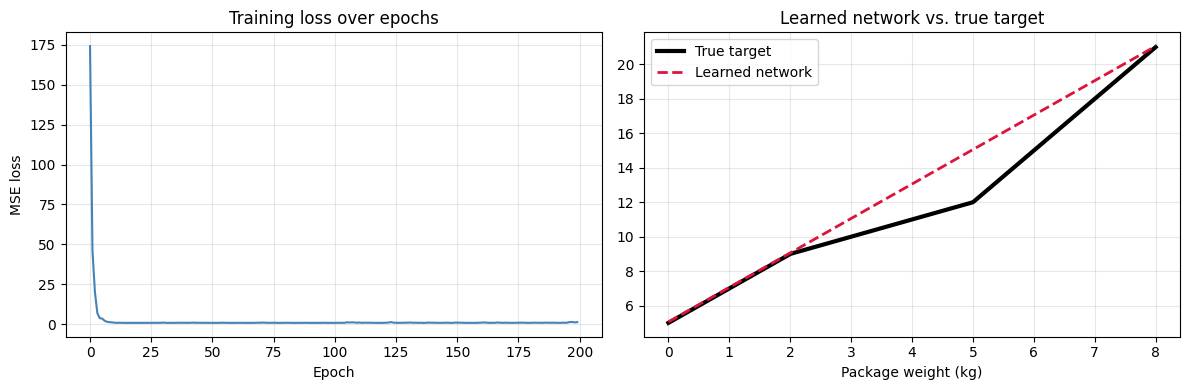

In [7]:
learned_prediction = model.predict(weights.reshape(-1, 1), verbose=0).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], color='steelblue')
axes[0].set_title('Training loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE loss')
axes[0].grid(alpha=0.3)

axes[1].plot(weights, target, color='black', linewidth=3, label='True target')
axes[1].plot(weights, learned_prediction, color='crimson', linestyle='--', linewidth=2, label='Learned network')
axes[1].set_title('Learned network vs. true target')
axes[1].set_xlabel('Package weight (kg)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Notice the learned curve is close to the tiered target, made up of straight segments joined
at bends — exactly the "stitched together linear pieces" behavior ReLU enables. With more
epochs, more units, or more training data, the fit gets tighter.

## Congratulations!

You've now seen the ReLU's non-linear "on/off" behavior from three angles:

1. How it compares to Linear and Sigmoid activations
2. How a hand-built sum of ReLU units can exactly reconstruct a piecewise linear target
3. How a real network learns that same shape automatically via gradient descent

The core idea carries over from the original lecture example: **ReLU's ability to stay silent
until a threshold is what lets a network stitch together linear pieces into a non-linear whole.**
